In [1]:
import pandas as pd
import io

# Dữ liệu của bạn
data = """param_1,param_2,train_acc,val_acc
1.4,0.8,0.9615,0.8359
1.4,0.9,0.9687,0.9001
1.4,1.0,0.9736,0.8999
1.4,1.1,0.9718,0.9067
1.4,1.2,0.9722,0.9089
1.4,1.3,0.9721,0.9085
1.4,1.4,0.9679,0.8990
1.4,1.5,0.9619,0.8921"""

# Đọc dữ liệu vào DataFrame
df = pd.read_csv(io.StringIO(data))

# CÁCH A: Tô màu xanh lá cho giá trị cao nhất (Tốt nhất)
styled_df = df.style.highlight_max(subset=['train_acc', 'val_acc'], color='lightgreen') \
                    .highlight_min(subset=['train_acc', 'val_acc'], color='lightcoral') \
                    .format("{:.4f}", subset=['train_acc', 'val_acc'])

# CÁCH B: Tạo dải màu (Heatmap/Gradient) từ thấp đến cao
# styled_df = df.style.background_gradient(cmap='Blues', subset=['train_acc', 'val_acc'])

# Hiển thị bảng (Chỉ cần gọi tên biến ở dòng cuối của cell)
styled_df

,param_1,param_2,train_acc,val_acc
0,1.400000,0.800000,0.9615,0.8359
1,1.400000,0.900000,0.9687,0.9001
2,1.400000,1.000000,0.9736,0.8999
3,1.400000,1.100000,0.9718,0.9067
4,1.400000,1.200000,0.9722,0.9089
5,1.400000,1.300000,0.9721,0.9085
6,1.400000,1.400000,0.9679,0.8990
7,1.400000,1.500000,0.9619,0.8921


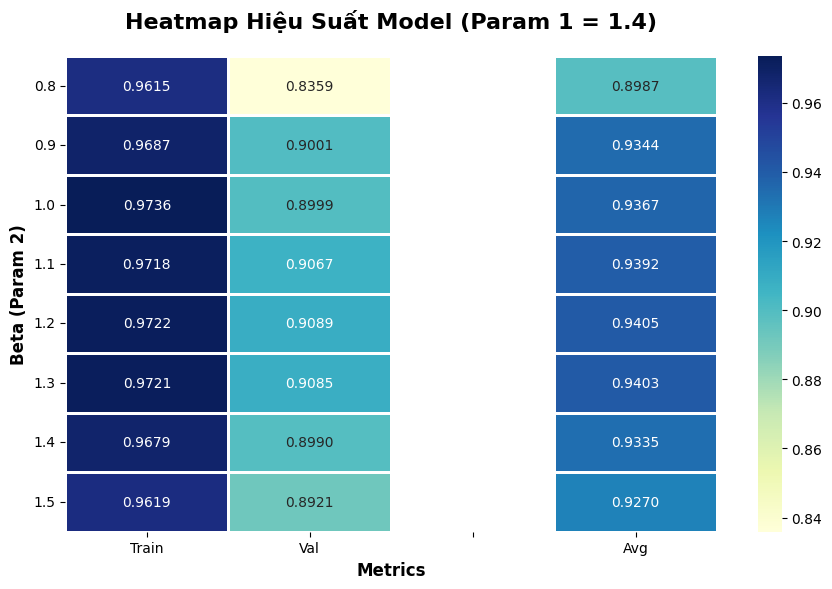

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# 1. Nạp dữ liệu (Mình bỏ qua param_1 vì nó cố định là 1.4)
data = """param_2,Train,Val
0.8,0.9615,0.8359
0.9,0.9687,0.9001
1.0,0.9736,0.8999
1.1,0.9718,0.9067
1.2,0.9722,0.9089
1.3,0.9721,0.9085
1.4,0.9679,0.8990
1.5,0.9619,0.8921"""

df = pd.read_csv(io.StringIO(data))

# Đặt trục Y là param_2 (Beta)
df.set_index('param_2', inplace=True)

# 2. Tính cột Trung bình (Avg)
df['Avg'] = df[['Train', 'Val']].mean(axis=1)

# 3. TRICK: Chèn một cột chứa giá trị NaN vào vị trí index số 2 để tạo khoảng trống
df.insert(2, '   ', np.nan) 

# 4. Bắt đầu vẽ Heatmap
plt.figure(figsize=(9, 6)) # Chỉnh kích thước khung hình

# Vẽ heatmap với Seaborn
ax = sns.heatmap(df, 
                 annot=True,           # Hiển thị số liệu trên ô
                 fmt=".4f",            # Format 4 chữ số thập phân
                 cmap="YlGnBu",        # Dải màu: Vàng (thấp) -> Xanh dương (cao)
                 mask=df.isnull(),     # Ẩn phần tô màu ở cột trống (NaN)
                 cbar=True,            # Hiện thanh chú thích màu bên phải
                 linewidths=2,         # Tạo đường viền giữa các ô
                 linecolor='white')    # Màu viền trắng cho sang

# 5. Căn chỉnh tiêu đề và text
plt.title('Heatmap Hiệu Suất Model (Param 1 = 1.4)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Beta (Param 2)', fontsize=12, fontweight='bold')
plt.xlabel('Metrics', fontsize=12, fontweight='bold')

# Để chữ ở trục X nằm ngang cho dễ đọc
plt.xticks(rotation=0) 
plt.yticks(rotation=0)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

IndexError: list index out of range

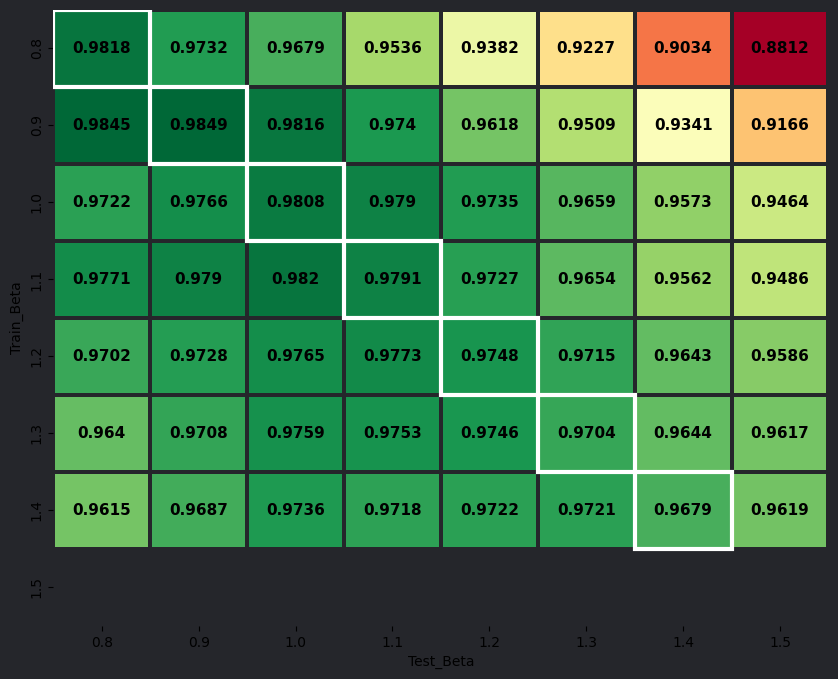

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import io

# 1. Nạp data của ông
data = """Train_Beta,Test_Beta,AUC,Accuracy
0.8,0.8,0.9818,0.9448
0.8,0.9,0.9732,0.9305
0.8,1.0,0.9679,0.9168
0.8,1.1,0.9536,0.8923
0.8,1.2,0.9382,0.8768
0.8,1.3,0.9227,0.8446
0.8,1.4,0.9034,0.7984
0.8,1.5,0.8812,0.7679
0.9,0.8,0.9845,0.9502
0.9,0.9,0.9849,0.9532
0.9,1.0,0.9816,0.9394
0.9,1.1,0.9740,0.9145
0.9,1.2,0.9618,0.8815
0.9,1.3,0.9509,0.8465
0.9,1.4,0.9341,0.7787
0.9,1.5,0.9166,0.7425
1.0,0.8,0.9722,0.9324
1.0,0.9,0.9766,0.9315
1.0,1.0,0.9808,0.9424
1.0,1.1,0.9790,0.9398
1.0,1.2,0.9735,0.9313
1.0,1.3,0.9659,0.9145
1.0,1.4,0.9573,0.8840
1.0,1.5,0.9464,0.8582
1.1,0.8,0.9771,0.9224
1.1,0.9,0.9790,0.9355
1.1,1.0,0.9820,0.9356
1.1,1.1,0.9791,0.9290
1.1,1.2,0.9727,0.9250
1.1,1.3,0.9654,0.9141
1.1,1.4,0.9562,0.8836
1.1,1.5,0.9486,0.8518
1.2,0.8,0.9702,0.9287
1.2,0.9,0.9728,0.9321
1.2,1.0,0.9765,0.9367
1.2,1.1,0.9773,0.9364
1.2,1.2,0.9748,0.9342
1.2,1.3,0.9715,0.9301
1.2,1.4,0.9643,0.9077
1.2,1.5,0.9586,0.8995
1.3,0.8,0.9640,0.9184
1.3,0.9,0.9708,0.9288
1.3,1.0,0.9759,0.9357
1.3,1.1,0.9753,0.9338
1.3,1.2,0.9746,0.9345
1.3,1.3,0.9704,0.9263
1.3,1.4,0.9644,0.9210
1.3,1.5,0.9617,0.9150
1.4,0.8,0.9615,0.8359
1.4,0.9,0.9687,0.9001
1.4,1.0,0.9736,0.8999
1.4,1.1,0.9718,0.9067
1.4,1.2,0.9722,0.9089
1.4,1.3,0.9721,0.9085
1.4,1.4,0.9679,0.8990
1.4,1.5,0.9619,0.8921"""

df = pd.read_csv(io.StringIO(data))

# 2. Xoay data thành ma trận 2D (Pivot) dùng cột AUC
pivot_df = df.pivot(index='Train_Beta', columns='Test_Beta', values='AUC')

# Thêm hàng 1.5 rỗng vào ma trận vì data chưa có
if 1.5 not in pivot_df.index:
    pivot_df.loc[1.5] = np.nan

# Đảm bảo các hàng/cột sắp xếp đúng thứ tự
pivot_df = pivot_df.sort_index(axis=0).sort_index(axis=1)

# 3. Cài đặt giao diện Dark Mode y hệt mẫu
bg_color = '#25262B'
fig, ax = plt.subplots(figsize=(10, 8), facecolor=bg_color)
ax.set_facecolor(bg_color)

# 4. Vẽ Heatmap (Màu: Đỏ -> Vàng -> Xanh)
sns.heatmap(pivot_df, 
            annot=True, 
            fmt=".4g",            # Bỏ bớt số 0 thừa
            cmap="RdYlGn",        # RdYlGn: Red (thấp) -> Yellow -> Green (cao)
            cbar=False,           # Ẩn thanh chú thích màu bên cạnh
            linewidths=1.5,       # Độ dày viền giữa các ô
            linecolor=bg_color,   # Màu viền tiệp với màu nền
            ax=ax,
            annot_kws={"fontsize": 11, "fontweight": "bold", "color": "black"})

# 5. Xử lý các chi tiết custom: Đổi "nan" thành "Wait..." và Vẽ viền trắng
rows = list(pivot_df.index)
cols = list(pivot_df.columns)

for i in range(len(rows)):
    for j in range(len(cols)):
        # a. Lấy text trong từng ô để kiểm tra
        text_obj = ax.texts[i * len(cols) + j]
        val = text_obj.get_text()
        
        # Nếu là ô trống (nan) -> Đổi thành Wait... và set màu trắng
        if val == 'nan':
            text_obj.set_text('Wait...')
            text_obj.set_color('white')
            text_obj.set_fontsize(10)
            text_obj.set_fontweight('normal')
            
            # Tô màu nền tối cho ô Wait (che màu heatmap mặc định)
            ax.add_patch(Rectangle((j, i), 1, 1, fill=True, color='#343746', lw=0))
            # Vẽ lại text lên trên lớp nền vừa tô
            ax.text(j + 0.5, i + 0.5, 'Wait...', color='white', ha='center', va='center')

        # b. Vẽ viền trắng cho đường chéo (Train = Test)
        if rows[i] == cols[j]:
            rect = Rectangle((j, i), 1, 1, fill=False, edgecolor='white', lw=3, zorder=10)
            ax.add_patch(rect)

# 6. Làm đẹp Text trục tung/hoành
ax.set_xlabel('TEST MARGIN (β)', color='white', fontweight='bold', labelpad=15)
ax.set_ylabel('TRAIN MARGIN (β)', color='white', fontweight='bold', labelpad=15)

# Đẩy trục X lên trên cho giống UI
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.xticks(color='white', fontsize=11)
plt.yticks(color='white', fontsize=11, rotation=0)
plt.title('Cross-Margin Evaluation Matrix (AUC)', color='white', fontsize=16, fontweight='bold', pad=30, loc='left')

plt.tight_layout()
plt.show()

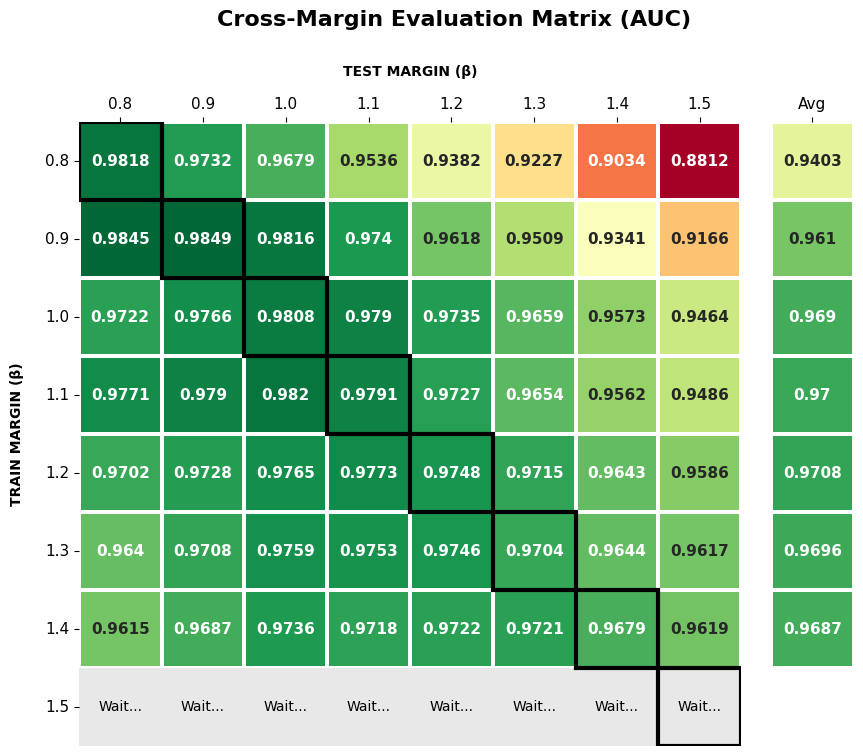

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import io

# 1. Nạp data
data = """Train_Beta,Test_Beta,AUC,Accuracy
0.8,0.8,0.9818,0.9448
0.8,0.9,0.9732,0.9305
0.8,1.0,0.9679,0.9168
0.8,1.1,0.9536,0.8923
0.8,1.2,0.9382,0.8768
0.8,1.3,0.9227,0.8446
0.8,1.4,0.9034,0.7984
0.8,1.5,0.8812,0.7679
0.9,0.8,0.9845,0.9502
0.9,0.9,0.9849,0.9532
0.9,1.0,0.9816,0.9394
0.9,1.1,0.9740,0.9145
0.9,1.2,0.9618,0.8815
0.9,1.3,0.9509,0.8465
0.9,1.4,0.9341,0.7787
0.9,1.5,0.9166,0.7425
1.0,0.8,0.9722,0.9324
1.0,0.9,0.9766,0.9315
1.0,1.0,0.9808,0.9424
1.0,1.1,0.9790,0.9398
1.0,1.2,0.9735,0.9313
1.0,1.3,0.9659,0.9145
1.0,1.4,0.9573,0.8840
1.0,1.5,0.9464,0.8582
1.1,0.8,0.9771,0.9224
1.1,0.9,0.9790,0.9355
1.1,1.0,0.9820,0.9356
1.1,1.1,0.9791,0.9290
1.1,1.2,0.9727,0.9250
1.1,1.3,0.9654,0.9141
1.1,1.4,0.9562,0.8836
1.1,1.5,0.9486,0.8518
1.2,0.8,0.9702,0.9287
1.2,0.9,0.9728,0.9321
1.2,1.0,0.9765,0.9367
1.2,1.1,0.9773,0.9364
1.2,1.2,0.9748,0.9342
1.2,1.3,0.9715,0.9301
1.2,1.4,0.9643,0.9077
1.2,1.5,0.9586,0.8995
1.3,0.8,0.9640,0.9184
1.3,0.9,0.9708,0.9288
1.3,1.0,0.9759,0.9357
1.3,1.1,0.9753,0.9338
1.3,1.2,0.9746,0.9345
1.3,1.3,0.9704,0.9263
1.3,1.4,0.9644,0.9210
1.3,1.5,0.9617,0.9150
1.4,0.8,0.9615,0.8359
1.4,0.9,0.9687,0.9001
1.4,1.0,0.9736,0.8999
1.4,1.1,0.9718,0.9067
1.4,1.2,0.9722,0.9089
1.4,1.3,0.9721,0.9085
1.4,1.4,0.9679,0.8990
1.4,1.5,0.9619,0.8921"""

df = pd.read_csv(io.StringIO(data))

# 2. Xoay data và tính toán
pivot_df = df.pivot(index='Train_Beta', columns='Test_Beta', values='AUC')

if 1.5 not in pivot_df.index:
    pivot_df.loc[1.5] = np.nan

pivot_df = pivot_df.sort_index(axis=0).sort_index(axis=1)

# Tách riêng df cho cột Avg (để vẽ vào subplot thứ 2)
avg_df = pd.DataFrame(pivot_df.mean(axis=1, skipna=True), columns=['Avg'])

# Tìm giá trị Min/Max tổng thể để màu sắc đồng bộ giữa 2 bảng
vmin = min(pivot_df.min().min(), avg_df.min().min())
vmax = max(pivot_df.max().max(), avg_df.max().max())

# 3. Tạo khung hình (Figure) nền trắng và chia làm 2 phần
# wspace=0.08 chính là khoảng cách giữa bảng chính và cột Avg (ông có thể tăng giảm tùy ý)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), 
                               gridspec_kw={'width_ratios': [8, 1], 'wspace': 0.08})
fig.patch.set_facecolor('white') # Set nền ngoài màu trắng

# --- VẼ BẢNG CHÍNH (ax1) ---
sns.heatmap(pivot_df, annot=True, fmt=".4g", cmap="RdYlGn", 
            mask=pivot_df.isnull(), cbar=False, vmin=vmin, vmax=vmax,
            linewidths=1.5, linecolor='white', ax=ax1,
            annot_kws={"fontsize": 11, "fontweight": "bold"}) 

for i, row_idx in enumerate(pivot_df.index):
    for j, col_idx in enumerate(pivot_df.columns):
        val = pivot_df.iloc[i, j]
        
        # Ô Wait... (Nền xám nhạt, chữ đen)
        if pd.isna(val):
            ax1.add_patch(Rectangle((j, i), 1, 1, fill=True, color='#E8E8E8', lw=0))
            ax1.text(j + 0.5, i + 0.5, 'Wait...', color='black', ha='center', va='center', fontsize=10)
            
        # Viền đường chéo (Đổi sang màu đen cho nổi trên nền sáng)
        # if row_idx == col_idx:
        #     rect = Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3, zorder=10)
        #     ax1.add_patch(rect)

# Decorate trục của bảng chính
ax1.set_xlabel('TEST MARGIN (β)', color='black', fontweight='bold', labelpad=15)
ax1.set_ylabel('TRAIN MARGIN (β)', color='black', fontweight='bold', labelpad=15)
ax1.xaxis.set_ticks_position('top')
ax1.xaxis.set_label_position('top')
ax1.tick_params(colors='black', labelsize=11)
plt.setp(ax1.get_yticklabels(), rotation=0)

# --- VẼ CỘT AVG (ax2) ---
sns.heatmap(avg_df, annot=True, fmt=".4g", cmap="RdYlGn", 
            cbar=False, vmin=vmin, vmax=vmax,
            linewidths=1.5, linecolor='white', ax=ax2,
            annot_kws={"fontsize": 11, "fontweight": "bold"})

# Decorate trục của cột Avg
ax2.set_xlabel('', color='black') # Ẩn tên trục X
ax2.set_ylabel('') # Ẩn tên trục Y
ax2.xaxis.set_ticks_position('top')
ax2.tick_params(colors='black', labelsize=11)
ax2.set_yticks([]) # Ẩn các số liệu trục Y đi cho đỡ lặp lại với bảng chính

# Tiêu đề tổng
fig.suptitle('Cross-Margin Evaluation Matrix (AUC)', color='black', fontsize=16, fontweight='bold', y=1.02)

# Chống lẹm chữ
plt.subplots_adjust(top=0.88, bottom=0.1)
plt.show()

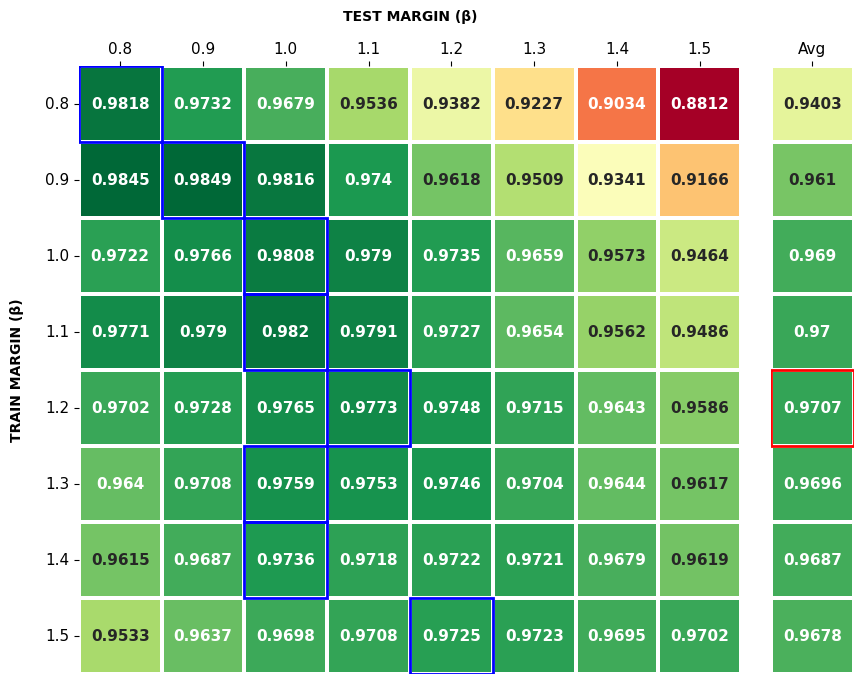

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import io

# 1. Nạp data
data = """Train_Beta,Test_Beta,AUC,Accuracy
0.8,0.8,0.9818,0.9448
0.8,0.9,0.9732,0.9305
0.8,1.0,0.9679,0.9168
0.8,1.1,0.9536,0.8923
0.8,1.2,0.9382,0.8768
0.8,1.3,0.9227,0.8446
0.8,1.4,0.9034,0.7984
0.8,1.5,0.8812,0.7679
0.9,0.8,0.9845,0.9502
0.9,0.9,0.9849,0.9532
0.9,1.0,0.9816,0.9394
0.9,1.1,0.9740,0.9145
0.9,1.2,0.9618,0.8815
0.9,1.3,0.9509,0.8465
0.9,1.4,0.9341,0.7787
0.9,1.5,0.9166,0.7425
1.0,0.8,0.9722,0.9324
1.0,0.9,0.9766,0.9315
1.0,1.0,0.9808,0.9424
1.0,1.1,0.9790,0.9398
1.0,1.2,0.9735,0.9313
1.0,1.3,0.9659,0.9145
1.0,1.4,0.9573,0.8840
1.0,1.5,0.9464,0.8582
1.1,0.8,0.9771,0.9224
1.1,0.9,0.9790,0.9355
1.1,1.0,0.9820,0.9356
1.1,1.1,0.9791,0.9290
1.1,1.2,0.9727,0.9250
1.1,1.3,0.9654,0.9141
1.1,1.4,0.9562,0.8836
1.1,1.5,0.9486,0.8518
1.2,0.8,0.9702,0.9287
1.2,0.9,0.9728,0.9321
1.2,1.0,0.9765,0.9367
1.2,1.1,0.9773,0.9364
1.2,1.2,0.9748,0.9342
1.2,1.3,0.9715,0.9301
1.2,1.4,0.9643,0.9077
1.2,1.5,0.9586,0.8995
1.3,0.8,0.9640,0.9184
1.3,0.9,0.9708,0.9288
1.3,1.0,0.9759,0.9357
1.3,1.1,0.9753,0.9338
1.3,1.2,0.9746,0.9345
1.3,1.3,0.9704,0.9263
1.3,1.4,0.9644,0.9210
1.3,1.5,0.9617,0.9150
1.4,0.8,0.9615,0.8359
1.4,0.9,0.9687,0.9001
1.4,1.0,0.9736,0.8999
1.4,1.1,0.9718,0.9067
1.4,1.2,0.9722,0.9089
1.4,1.3,0.9721,0.9085
1.4,1.4,0.9679,0.8990
1.4,1.5,0.9619,0.8921
1.5,0.8,0.9533,0.8766
1.5,0.9,0.9637,0.9165
1.5,1.0,0.9698,0.9199
1.5,1.1,0.9708,0.9231
1.5,1.2,0.9725,0.9278
1.5,1.3,0.9723,0.9291
1.5,1.4,0.9695,0.9208
1.5,1.5,0.9702,0.9213
"""

df = pd.read_csv(io.StringIO(data))

# 2. Xoay data và tính toán
pivot_df = df.pivot(index='Train_Beta', columns='Test_Beta', values='AUC')

if 1.5 not in pivot_df.index:
    pivot_df.loc[1.5] = np.nan

pivot_df = pivot_df.sort_index(axis=0).sort_index(axis=1)

# Lấy cột Max của từng hàng bên bảng chính
max_cols_per_row = {}
for r_idx in pivot_df.index:
    row_vals = pivot_df.loc[r_idx]
    if not row_vals.isna().all():
        max_cols_per_row[r_idx] = row_vals.idxmax()

# Tách riêng df cho cột Avg
avg_df = pd.DataFrame(pivot_df.mean(axis=1, skipna=True), columns=['Avg'])

vmin = min(pivot_df.min().min(), avg_df.min().min())
vmax = max(pivot_df.max().max(), avg_df.max().max())

# 3. Tạo khung hình
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), 
                               gridspec_kw={'width_ratios': [8, 1], 'wspace': 0.08})
fig.patch.set_facecolor('white')

# --- VẼ BẢNG CHÍNH (ax1) ---
sns.heatmap(pivot_df, annot=True, fmt=".4g", cmap="RdYlGn", 
            mask=pivot_df.isnull(), cbar=False, vmin=vmin, vmax=vmax,
            linewidths=1.5, linecolor='white', ax=ax1,
            annot_kws={"fontsize": 11, "fontweight": "bold"}) 

for i, row_idx in enumerate(pivot_df.index):
    col_max_of_this_row = max_cols_per_row.get(row_idx)
    
    for j, col_idx in enumerate(pivot_df.columns):
        val = pivot_df.iloc[i, j]
        
        # Ô Wait...
        if pd.isna(val):
            ax1.add_patch(Rectangle((j, i), 1, 1, fill=True, color='#E8E8E8', lw=0))
            ax1.text(j + 0.5, i + 0.5, 'Wait...', color='black', ha='center', va='center', fontsize=10)
            
        # Viền đen đường chéo
        # if row_idx == col_idx:
        #     rect_diag = Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=2, zorder=10)
        #     ax1.add_patch(rect_diag)
            
        # Viền xanh cho Max của hàng
        if col_idx == col_max_of_this_row:
            rect_max = Rectangle((j, i), 1, 1, fill=False, edgecolor='blue', lw=2, zorder=15)
            ax1.add_patch(rect_max)

ax1.set_xlabel('TEST MARGIN (β)', color='black', fontweight='bold', labelpad=15)
ax1.set_ylabel('TRAIN MARGIN (β)', color='black', fontweight='bold', labelpad=15)
ax1.xaxis.set_ticks_position('top')
ax1.xaxis.set_label_position('top')
ax1.tick_params(colors='black', labelsize=11)
plt.setp(ax1.get_yticklabels(), rotation=0)

# --- VẼ CỘT AVG (ax2) ---
sns.heatmap(avg_df, annot=True, fmt=".4g", cmap="RdYlGn", 
            cbar=False, vmin=vmin, vmax=vmax,
            linewidths=1.5, linecolor='white', ax=ax2,
            annot_kws={"fontsize": 11, "fontweight": "bold"})

# TÌM VÀ VẼ VIỀN CHO MAX CỦA CỘT AVG
max_avg_val = avg_df['Avg'].max()
for i, val in enumerate(avg_df['Avg']):
    if val == max_avg_val: # Lỡ có 2 ô bằng điểm nhau thì nó bôi đỏ hết
        # Tọa độ x=0 vì cột Avg chỉ có 1 cột duy nhất
        rect_avg_max = Rectangle((0, i), 1, 1, fill=False, edgecolor='red', lw=2, zorder=15)
        ax2.add_patch(rect_avg_max)

ax2.set_xlabel('', color='black')
ax2.set_ylabel('')
ax2.xaxis.set_ticks_position('top')
ax2.tick_params(colors='black', labelsize=11)
ax2.set_yticks([]) 

# Update lại title cho chuẩn
# fig.suptitle('Cross-Margin Evaluation Matrix (AUC)', 
#              color='black', fontsize=14, fontweight='bold', y=1.03)

plt.subplots_adjust(top=0.86, bottom=0.1)
plt.show()